# Top-idx Feature Tracker Plots (Target vs Contrast)
Load extracted vector metadata and plot both target/contrast activation_frequency and feature_mean for each top_idx feature.

In [1]:
import json
from pathlib import Path

import pandas as pd
import seaborn as sns
import torch
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

In [2]:
# Update this path to any extracted vector metadata file
VECTOR_METADATA_PATH = Path('Vector/SAS/Llama/refusal_response/metadata.pt')
LAYER = '7'  # can be str or int
TOP_N = 15

/data/caotue/anaconda3/envs/sae_circuit/lib/python3.11/site-packages/torch/_utils.py:358: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  result = torch.sparse_coo_tensor(


,feature_index,target_activation_frequency,contrast_activation_frequency,target_feature_mean,contrast_feature_mean,feature_rank
0,8875,0.170000,0.007143,0.304654,0.002969,0
1,504,0.012857,0.272857,0.007623,0.257932,1
2,10619,0.130000,0.005714,0.083524,0.002559,2
3,14055,0.074286,0.121429,0.045296,0.076822,3
4,13162,0.164286,0.000000,0.103560,0.000000,4
5,12760,0.121429,0.008571,0.074202,0.004581,5
6,2082,0.221429,0.000000,0.122743,0.000000,6
7,13089,0.105714,0.000000,0.056576,0.000000,7
8,11220,0.031429,0.148571,0.025346,0.078440,8
9,15067,0.220000,0.000000,0.104658,0.000000,9


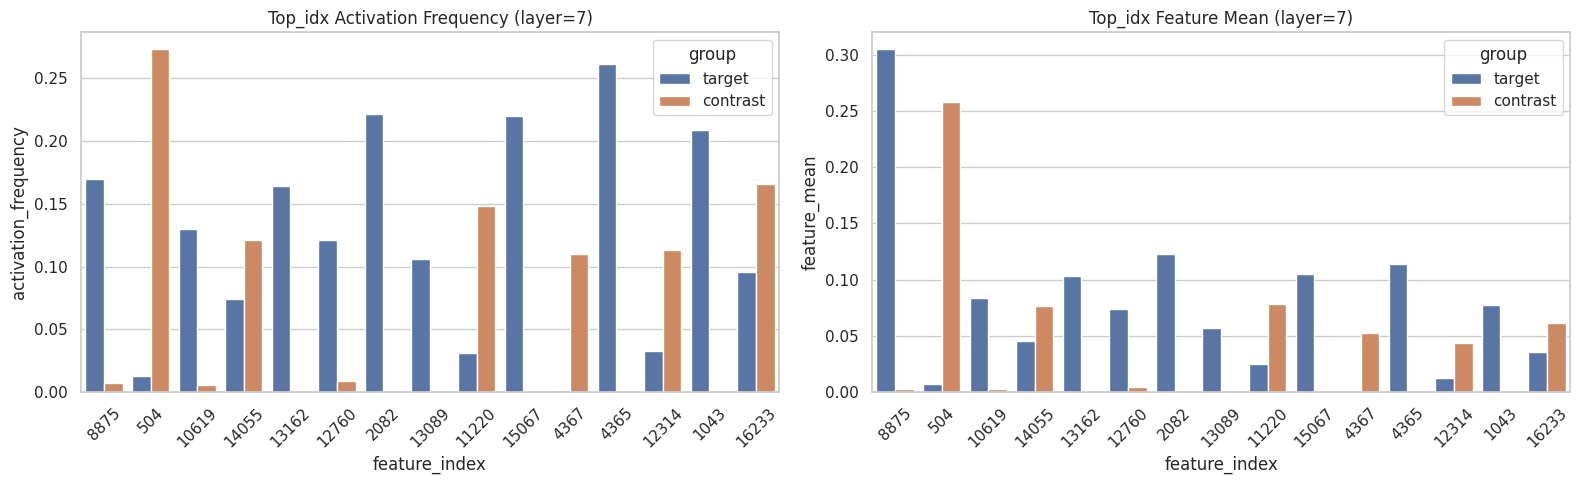

In [3]:
with VECTOR_METADATA_PATH.open('rb') as f:
    metadata = torch.load(f)

def get_layer_block(block, layer_key):
    if not isinstance(block, dict):
        return None
    return block.get(str(layer_key), block.get(int(layer_key), None))

top_idx_block = metadata.get('top_idx', {})
feature_tracker_block = metadata.get('feature_tracker', {})

top_idx = get_layer_block(top_idx_block, LAYER)
tracker = get_layer_block(feature_tracker_block, LAYER)

if top_idx is None:
    raise ValueError(f'top_idx not found for layer={LAYER}')
if tracker is None:
    raise ValueError(f'feature_tracker not found for layer={LAYER}. Re-extract vector with tracker metadata enabled.')

# Keep extractor scoring order exactly as stored in metadata (no index sorting).
top_idx = [int(x) for x in top_idx[:TOP_N]]
tracker_map = {int(row['feature_index']): row for row in tracker if 'feature_index' in row}

rows = []
for feat in top_idx:
    row = tracker_map.get(feat)
    if row is None:
        continue

    rows.append({
        'feature_index': feat,
        # Frequency fields
        'target_activation_frequency': float(row.get('target_activation_frequency', row.get('activation_frequency', 0.0))),
        'contrast_activation_frequency': float(row.get('contrast_activation_frequency', 0.0)),
        # Mean fields
        'target_feature_mean': float(row.get('target_feature_mean', row.get('feature_mean', 0.0))),
        'contrast_feature_mean': float(row.get('contrast_feature_mean', 0.0)),
    })

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError('No matching feature_tracker rows found for top_idx.')

# Explicit rank axis avoids seaborn/matplotlib categorical auto-sorting.
df['feature_rank'] = range(len(df))

freq_plot_df = df.melt(
    id_vars=['feature_rank', 'feature_index'],
    value_vars=['target_activation_frequency', 'contrast_activation_frequency'],
    var_name='group',
    value_name='activation_frequency',
)
freq_plot_df['group'] = freq_plot_df['group'].map({
    'target_activation_frequency': 'target',
    'contrast_activation_frequency': 'contrast',
})

mean_plot_df = df.melt(
    id_vars=['feature_rank', 'feature_index'],
    value_vars=['target_feature_mean', 'contrast_feature_mean'],
    var_name='group',
    value_name='feature_mean',
)
mean_plot_df['group'] = mean_plot_df['group'].map({
    'target_feature_mean': 'target',
    'contrast_feature_mean': 'contrast',
})

display(df)

fig, axes = plt.subplots(1, 2, figsize=(max(16, len(df) * 0.9), 5))

sns.barplot(
    data=freq_plot_df,
    x='feature_rank',
    y='activation_frequency',
    hue='group',
    ax=axes[0],
)
axes[0].set_title(f'Top_idx Activation Frequency (layer={LAYER})')
axes[0].set_xlabel('feature_index')
axes[0].set_ylabel('activation_frequency')
axes[0].set_xticks(df['feature_rank'])
axes[0].set_xticklabels(df['feature_index'].astype(str), rotation=45)

sns.barplot(
    data=mean_plot_df,
    x='feature_rank',
    y='feature_mean',
    hue='group',
    ax=axes[1],
)
axes[1].set_title(f'Top_idx Feature Mean (layer={LAYER})')
axes[1].set_xlabel('feature_index')
axes[1].set_ylabel('feature_mean')
axes[1].set_xticks(df['feature_rank'])
axes[1].set_xticklabels(df['feature_index'].astype(str), rotation=45)

plt.tight_layout()
plt.show()